# Oblig 3b - Forsterkende Læring (Reinforcement Learning)


## Innlevering

Oppgaven leveres innen 29. april klokken 23.59 i [Devilry](https://devilry.ifi.uio.no/).

Innleveringen skal bestå av én Jupyter notebook med både kode og tilhørende forklaringer. **Før innlevering skal du kjøre gjennom hele notebooken, før du lagrer siste gang. Den bør kjøre uten å feile og vise den grafikken og de utskriftene som skal være med.**

Vi understreker at innlevering av kode alene ikke er nok for å bestå oppgaven – vi forventer at notebooken også skal inneholde kommentarer (på norsk eller engelsk) på hva dere har gjort og begrunnelser for valgene dere har tatt underveis.
La enhver oblig bli en trening i å formidle forskning. Bruk helst hele setninger, og matematiske formler om nødvendig. Resultater skal presenteres i tabeller på en oversiktlig måte.
Det å forklare med egne ord, bruke begreper vi har gått gjennom på forelesningene og å forklare og reflektere over løsningene deres er en viktig del av læringsprosessen – ta det på alvor!

Når det gjelder bruk av generative prateroboter (ChatGPT og lignende): Dere kan bruke dem som en "sparringspartner", for eksempel for å forklare noe dere ikke helt har forstått. Dere har imidlertid ikke lov til å bruke dem til å generere løsninger (enten delvis eller fullstendig) til noen av oppgavene. Funksjoner for automatisk skriving av kode, som Copilot i VS Code, må derfor også være deaktivert mens dere jobber på obligen.

Bruker dere KI-verktøy vil vi også at dere kort beskriver hvordan dere har brukt dem under arbeidet med oppgaven.

Det er ikke mulighet for omlevering av obliger som ikke bestås.

Her dere spørsmål til obligen eller finner noe dere tror er feil, må dere gjerne si ifra på [Discourse](https://discourse.uio.no/c/in1160-26v/820).



## Introduksjon

I denne obligen skal vi implementere tabulære algoritmer for forsterkende læring (reinforcement learning), som vi skal bruke på noen enkle spill. Vi kommer til å implementere strategier (policies), som påvirker hvordan valg er tatt, og algoritmene *Q-learning* og *SARSA* som oppdaterer tilstand-handling (state-action) verdiene.

Vi kommer til å bruke `gymnasium`-biblioteket i Python til å teste agentene våre. Dette rammeverket baserer seg på OpenAI sin `gym`, som var en samling av forsterkningslæringsproblemer på et standardisert format. OpenAI sluttet å vedlikeholde biblioteket i 2022, og det blir nå utviklet som `gymnasium` av *Farama Foundation*. Biblioteket tilbyr mange lærerike problemer for utvikling av forsterkningslæringsagenter, og formatet for hvordan *miljøer* (environments) er implementert har blitt en standard.

I del 1 skal vi implementere funksjonaliteten vi skal bruke, som er strategier (policies) og oppdateringsregler. I del 2 ser vi på hvordan miljøene fra `gymnasium` fungerer. For enkelhets skyld får dere ferdig kode som implementerer kjøring av episoder og trening av agenter, men det er anbefalt å ta en kort titt på hvordan koden fungerer. Deretter skal vi trene agenter med ulike konfigurasjoner på forskjellige spill og tolke resultatene.

Som med oblig 2a og 2b følger det med tester dere kan bruke til å hjelpe dere med implementasjonen av koden. Det er nødvendig at testene skal passere for å bestå oppgavene, men det at testene passerer er ikke en garanti for at koden er implementert helt riktig. For å unngå feil bør dere ikke endre på noen funksjons- eller variabelnavne fra prekoden.

**Poeng:** Obligen gir maksimalt 25 poeng og 5 bonus poeng. For å bestå kreves det totalt 30 av 50 poeng fra oblig 3a og 3b tilsammen. Bonuspoengene telles ikke med i denne beregningen. Poengfordelingen er markert i overskriften til oppgaven, der `p` indikerer vanlig poeng og `b` indikerer bonuspoeng.


In [146]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from tests3b import (
    test_epsilon_greedy_policy,
    test_greedy_policy,
    test_q_learning_update,
    test_random_policy,
    test_sarsa_update,
    test_softmax_policy,
)
from utils3b import plot_rewards, train_agent, visualize_episode


## Del 1 - Implementasjon av forsterkningslæringsalgoritmer [Totalt 15p og 2b]

La oss ta en kort repetisjon av terminologien. Vi har en *agent* som handler i et *miljø* (environment). Agenten er instansen som tar valg. Miljøet gir oss *tilstander* (states) og *belønninger* (rewards). Gitt en tilstand kan agenten gjøre en *handling* (action). Gitt en tilstand og en handling vil miljøet vårt returnere en ny tilstand og en ny belønning. Vi kan bruke belønningene og tilstandene til å trene agenten til å lære hvilke handlinger som er smarte å gjøre.

Metodene vi bruker i dette faget bruker en *Q-tabell* til å trene opp agenten. Dette er en tabell over kombinasjoner av tilstander og handlinger. Tabellen vil ha en verdi av hver mulige handling for hver mulige tilstand. Vi kan initialisere dette som 0 eller små tilfeldige verdier. Deretter itererer vi over miljøet vårt. Vi lar agent ta valg ifølge *strategien* (policy) vår, som vil gi oss et valg gitt en tilstand og den nåværende Q-tabellen vår. Vi vil så bruke læringsalgoritmene Q-learning og SARSA til å oppdatere Q-tabellen. Når vi har tatt nok valg til å ende opp i en slutt-tilstand, eller nådd maks iterasjoner, er vi ferdig med én *episode*. Vi itererer over mange episoder for å trene agentene våre. I hvert steg i hver episode vil vi altså være i en tilstand og bruke strategien og nåværende Q-tabell til å få en handling, utføre handlingen i miljøet som gir oss en belønning og en ny tilstand, og bruke denne informasjonen til å oppdatere Q-tabellen vår.

### 1.1 - Strategier (policies) [6p, 2b]

La oss starte med å implementere strategiene våre. En strategi (policy) er det som blir brukt av agenten til å gjøre handlinger. Gitt en tilstand og en Q-tabell vil strategien returnere et valg.

Strategiene våre vil ta `q_table` og `state` som argumenter. Argumentet `q_table` vil være en to-dimensjonal NumPy array av størrelse `[n_states x n_actions]`. Vi vil altså få Q-verdien for tilstand `x` og handling `y` ved `q_table[x][y]`. Tilstandene (`state`) vil være representert med heltall. Strategiene returnerer handlinger, som også er representert av heltall.

**Oppgave 1.1.1**: Implementer `random_policy()`, som returnerer en tilfeldig valgt handling. Bruk `np.random.randint()` til å trekke en tilfeldig verdi.  

*Hint*: Dere kan bruke `q_table.shape[1]` for å finne antall mulige handlinger. Dere kan prøve å kalle strategifunksjonene med `q_table=example_q_table` for å ha en Q-tabell å teste med under implementasjonen. Denne Q-tabellen har fire tilstander (representert av hver rad) og tre handlinger per tilstand (representert med hver kolonne).

In [147]:
example_q_table = np.array(  # Can be used for testing when implementing the policy functions
    [
        [1, 0, 0],  # State one has three actions, with Q-values 1, 0 and 0, respectivly.
        [0, 2, 0],
        [0, 0, 3],
        [-1, -2, -3],
    ]
)


def random_policy(q_table, state):
    """
    Policy that returns a random choice.

    Args:
        q_table (np.array): [n_states x n_actions]-shaped array of q-values.
        state (int): The state. Not used for this policy, but included to
            make the policy fit the pattern of the other policies.

    Returns:
        int: The action chosen, represented as an int between 0 and `n_actions`.
    """
    # Finner antall mulige handlinger ved å se på antall kolonner i Q-tabellen
    n_actions = q_table.shape[1]

    # Trekker et tilfeldig heltatt fra 0 til n_actions - 1
    return np.random.randint(0, n_actions)


test_random_policy(input_function=random_policy);


**Oppgave 1.1.2**: Implementer `greedy_policy()`, som returnerer handlingen med høyest tilsvarende Q-verdi. 

*Hint*: Dere kan bruke `np.argmax()`. Dersom det er likt mellom de høyeste Q-verdiene kan dere velge den første av dem.

In [148]:
def greedy_policy(q_table, state):
    """
    Policy that returns the action corresponding to the highest q-value.

    Args:
        q_table (np.array): [n_states x n_actions]-shaped array of q-values.
        state (int): The state. The q-values for the actions will be `q_table[state]`.

    Returns:
        int: The action chosen, represented as an int between 0 and `n_actions`.
    """

    # Henter alle Q-verdiene for den nåværende tilstanden
    state_action_values = q_table[state]

    # Returnerer indeksen til den største Q-verdien
    # np.argmax returnerer første indeks hvis flere verdier er like store
    return np.argmax(state_action_values)


test_greedy_policy(input_function=greedy_policy);

**Oppgave 1.1.3**: Implementer strategien `EpsilonGreedyPolicy`, som tar et tilfeldig valg med sannsynligheten $\epsilon$ (som er den greske bokstaven uttalt *epsilon*) og tar det "grådigste valget" (altså handlingen med høyest Q-verdi) med sannsynlighet 1 - $\epsilon$. Siden denne strategien avhenger av en parameter $\epsilon$ som de andre strategiene ikke bruker, implementerer vi det som en klasse. Vi kan initialisere strategien ved `epsilon_greedy_policy = EpsilonGreedyPolicy(0.1)` og deretter bruke `epsilon_greedy_policy` som en funksjon, siden klassen implementerer `__call__()`.

*Hint*: Dere kan bruke `np.random.random()` til å trekke en tilfeldig verdi mellom 0 og 1, for å så sammenligne den med $\epsilon$. Dere kan også bruke funksjonene fra oppgave 1.1.1 og 1.1.2 som del av denne implementasjonen.

In [149]:
class EpsilonGreedyPolicy:
    """
    Epsilon greedy policy, chooses a random action with probability `epsilon`
    and chooses the action corresponding to the highest q-value with `1 - epsilon` probablity.

    This is implemented as a class so that the hyperparameter `epsilon` can be stored as a
    class variable and therefore have the callable on the same format as the other policies.
    """

    def __init__(self, epsilon):
        if not isinstance(epsilon, (float, int)):
            raise TypeError(f"Argument `epsilon` must be a float or int, got `{type(epsilon)}`.")
        if not (0.0 <= epsilon <= 1.0):
            raise ValueError(f"Argument `epsilon` must be between 0 and 1 inclusive, got `{epsilon}`.")
        self.epsilon = epsilon

    def __call__(self, q_table, state):
        # Trekker et tilfeldig tall mellom 0 og 1
        tilfeldig_tall = np.random.random()

        # Velger tilfeldig handling med epsilon
        if tilfeldig_tall < self.epsilon:
            return random_policy(q_table=q_table, state=state)

        # Eller så velges den beste kjente handlingen
        return greedy_policy(q_table=q_table, state=state)


test_epsilon_greedy_policy(input_class=EpsilonGreedyPolicy)  # This test uses the previous random and greedy tests

**[Bonus] Oppgave 1.1.4**: Implementer strategien `SoftmaxPolicy`, som gjør en handling proporsjonalt med størrelsen til Q-verdiene ved å bruke softmax-funksjonen. For handlinger $(a_1, a_2, ..., a_m)$ med tilhørende Q-verdier $(q_1, q_2, ..., q_m)$ vil sannsynligheten for en handling $a_j$ være gitt ved $p(a_j) = e^{a_j / \tau} / \sum_{i = 1}^m e^{a_i / \tau}$. Her er $\tau$ (den greske bokstaven uttalt *tau*) *temperaturen*, som avgjør hvor ofte strategien velger handlinger tilsvarende lave Q-verdier. Dersom $\tau$ går mot uendelig går strategien mot den tilfeldige strategien, og dersom $\tau$ går mot 0 går strategien mot en grådig strategi. Siden strategien avhenger av hyperparameteren $\tau$ implementerer vi det som en klasse, slik som med `EpsilonGreedyPolicy`.

**Hint**: Etter å ha regnet ut softmax-sannsynlighetene `probabilities`, kan dere bruke `np.random.choice(np.arange(n_actions), p=probabilities)` til å trekke et tilfeldig valg.

In [150]:
class SoftmaxPolicy:
    """
    Softmax policy, also known as the Boltzman policy. Chooses an action with a probability
    corresponding to the softmaxed values of the q-values associated with the actions.
    probability(a_i) = softmax(a_i) = e^(a_i / t) / sum_(j = 1)^n e^(a_j / t)

    This is implemented as a class so that the hyperparameter `temperature` can be stored as a
    class variable and therefore have the callable on the same format as the other policies.
    """

    def __init__(self, temperature):
        self.temperature = temperature

    def __call__(self, q_table, state):
        pass


test_softmax_policy(input_class=SoftmaxPolicy)

Failed: `test_softmax_policy`. Not implemented (returned `None`). 


### Forklaring - Oppgave 1

#### Oppgave 1.1.1 - random_policy()

Denne funksjonen velger en hanling helt tilfeldig, uten å ta hensyn til hvilke Q-verdier som finnes i tabellen. Først vinner funksjonen hvor mange mulige handliger som finnes ved å se på antall kolonner i q_table med q_table.shape[1]. Deretter bruker den np.random.randint(0, n_actions) for å trekke et tilfeldig heltall mellom 0 og n_actions - 1. Dette tallet representerer handlingen agenten skal utføre. Tilstanden 'state' brukes ikke i denne strategien, siden strategien skal være helt tilfeldig uansett hvilken tilstand agenten befinner seg i. Dette er en ren utforskningsstrategi.


#### Oppgave 1.1.2 - greedy_policy()

Denne funksjonen velger handlingen som ser best ut akkurat nå ut fra Q-tabellen. Først henter funksjonen raden i Q-tabellen som hører til den aktuelle tilstanden, altså q_table[state]. Denne raden inneholder Q-verdiene for alle mulige handlinger i akkurat den tilstanden. Deretter brukes np.argmax(...) til å finne indeksen til den største verdien i raden. Indeksen som returneres er handlingen med høyest Q-verdi, altså den handlingen agenten mener er best akkurat nå. Hvis flere handlinger har samme høyeste verdi, velger np.argmax() den første av dem. Dette er en ren utnyttelsesstrategi, fordi agenten alltid velger det som ser mest lovende ut.


#### Oppgave 1.1.3 - EpsilonGreedyPolicy

Denne strategien kombinerer utforskning og utnyttelse. Klassen lagrer en parameter epsilon, som bestemmer hvor ofte agenten skal velge tilfeldig. Når strategien kalles, trekkes først et tilfeldig tall mellom 0 og 1 med nå.random.random(). hvis dette tallet er mindre enn epsilon, velger agenten en tilfeldig handling ved å bruke random_policy(q_table, state). Da utforsker agenten og prøver noe nytt. Hvis tallet er større enn eller lik epsilon, velger agenten den grådige handlingen ved å bruke greedy_policy(q_table, state). Da utnytter agenten det den allerede har lært. På denne måten får vi en balanse mellom å teste nye handlinger og å velge den handlingen som ser best ut ut fra den nåværende Q-tabellen.


------------------------------------------------------------------

### 1.2 - Læringsalgoritmer [10p]

Vi skal nå implementere læringsalgoritmene. Agenten vil bruke en strategi til velge og utføre en handling, og deretter bruke belønningen mottatt av miljøet til å oppdatere Q-tabellen. Q-tabellen inneholder estimater på forventet belønning for et gitt par av tilstand og handling. Vi skal implementere oppdateringsreglene til algoritmene Q-læring og SARSA. Algoritmene er nesten identiske, bortsett fra ett ledd.

La oss repetere litt notasjon og intuisjon. La oss si vi befinner oss i tilstand $S$, der strategien vår gir oss handling $A$. Denne handlingen vil gi oss en belønning $R$ og en ny tilstand. Målet vårt er at Q-tabellen vår skal inneholde *forventet belønning for resten av episoden*, gitt en tilstand og handling. Vi kunne ha satt $Q[S, A]$ (Q-verdien til tilstand $S$ og handling $A$) til å være lik $R$, altså belønningen vi fikk ved å være i tilstand $S$ og gjøre handling $A$, men det vil ha noen svakheter. Blant annet er vi ikke gitt å motta samme belønning med samme tilstand og handling. Miljøet kan ha tilfeldigheter som gjør at belønningene vil variere. 
Dette kan vi løse ved oppdatere Q-verdien med en *læringsrate*, altså med følgende:

$$Q[S, A] \leftarrow Q[S, A] + \alpha(R - Q[S, A])$$

Her er $\alpha$ (den greske bokstaven uttalt "alpha") læringsraten vår (i maskinlæring brukes det ulike symboler for læringsraten, stort sett enten $\alpha$, $\eta$ eller $\mu$ - sistnevnte ble brukt i formelen for Q-læring i forelesningen). Om vi ganger ut $\alpha$ i parentesen får vi $(1 - \alpha) Q[S, A] + \alpha R$, så vi ser at vi oppdaterer Q-verdien i retning mot belønningen $R$ som vi mottok, men vi beholder også litt av den tidligere Q-verdien. På denne måten vil vi jevne ut belønningene som vil være en stor fordel dersom de vil variere. Læringsraten vil også hjelpe til å jevne ut tilfeldigheten relatert til hvilke valg som blir tatt frem i tid når vi legger til leddet i neste steg.

Vi trenger et steg til for oppdateringsreglene våre. Q-verdien skal ikke være hva forventet belønning er i *neste steg*, men igjennom *resten av episoden*. La oss illustrere dette med et eksempel. Om vi spiller sjakk er det vanlig å ha belønning 1 dersom man vinner og 0 ellers. En tommelfinger-regel i forsterkende læring er at belønningene skal reflektere ønsket *utfall*, men ikke *hvordan man skal oppnå dette utfallet*. Om vi hadde satt Q-verdiene til å kun representere forventet belønning *neste* steg hadde nesten alle verdiene vært 0, og agenten ville ikke kunne lære noe annet enn sjakk-posisjoner der den kan vinne i ett steg.

For å få oppdateringsregelen til å representere forventet belønning for resten av episoden kan vi legge til et ledd som representerer Q-verdien i neste steg. Dette leddet ser litt forskjellig ut i SARSA og Q-læring, men la oss kalle det for $Q^*$. Belønningen for resten av episoden kan nå representere med $R + Q^*$. Det kan virke som dette kun vil representere belønningen for dette steget og ett steg til, men siden $Q^*$ igjen vil avhenge av neste steg, som vil avhenge av steget etter det igjen, og så videre, vil vi rekursivt representere resten av belønningene. Siden fremtiden ofte er noe usikker, vil vi vekte ned Q-verdier som er mange steg unna. Dette gjør vi med en hyperparameter $\gamma$ (den greske bokstaven uttalt "gamma") kalt *diskonteringsfaktoren* (discount factor). Vi bruker altså $R + \gamma Q^*$ som et mål på belønningen for resten av episoden, og vi får følgende oppdateringsregelen:

$$Q[S, A] \leftarrow Q[S, A] + \alpha (R + \gamma Q^* - Q[S, A])$$

Siden $R + \gamma Q^*$ ganges med læringsraten $\alpha$, vil læringsraten også jevne ut tilfeldighetene ved valgene ved resten av episoden. Om man for eksempel gjør et smart valg med en moderat høy belønning og så et dårlig valg med en veldig negativ belønning, vil dette gjøre at vi justerer Q-verdien til det smarte valget nedover. Om vi senere gjør det samme smarte valget med også etterfulgt av et godt valg, vil vi justere Q-verdien oppover. Derfor lønner det seg at vi oppdaterer Q-verdiene i følge en læringsrate, slik at vi jevner ut de forskjellige mulighetene, istedenfor å overskrive dem til $R + \gamma Q^*$ med en gang.

Når vi setter estimater på $Q^*$ får vi algoritmene SARSA og Q-læring. Dette er noen av de viktigste algoritmene i forsterkende læring.

**Oppgave 1.2.0**: Det er lurt å bruke litt tid på å forstå intuisjonen bak algoritmene, så la oss gjøre et par oppgaver relatert til dem.

- a) Hva er rollen til hyperparameteren $\alpha$? Hva skjer om den settes til 1? Hva om den settes til 0?
- b) Hva er rollen til hyperparameteren $\gamma$? Hva skjer om den settes til 1? Hva om den settes til 0?

### Svar - Oppgave 1.2.0

#### Oppgave 1.2.0 a)
Hyperparameteren a er læringsraten, og bestemmer hvor mye ny informasjon skal påvirke Q-verdien når den oppdateres. Den styrer altså hvor stort steg vi skal ta mot den nye målverdien. 
Hvis a settes til 1, erstattes den gamle Q-verdien fullt ut av den nye estimerte verdien, slik at agenten bare bruker det siste den observerte og ikke glatter ut over tidligere erfaringer. 
Hvis a settes til 0, blir Q-verdien aldri oppdatert, og agenten lærer dermed ingenting.

#### Oppgave 1.2.0 b)
Hyperparameteren y er diskonteringsfaktoren, og bestemmer hvor mye fremtidige belønninger skal telle sammenlignet med den umiddelbare belønningen. En høy y gjør at agenten bryr seg mer om langsiktige konsekvenser av valgene sine, mens en lav y gjør at agenten fokuserer mer på belønningen den får med en gang. 
Hvis y settes til 1, blir fremtidige belønninger ikke diskontert i det hele tatt, slik at agenten verdsetter fremtiden like mye som nåtiden. 
Hvis y settes til 0, ser agenten bare på den umiddelbare belønningen R, og tar ikke hensyn til hva som kan skje senere i episoden.

#### 1.2.1 SARSA

Oppdateringsregelen for SARSA er gitt ved:

$$Q[S, A] \leftarrow Q[S, A] + \alpha (R + \gamma Q[S', A'] - Q[S, A])$$

Der $S'$ er tilstanden vi ender opp i etter å ha utført handlingen $A$ i tilstand $S$, og $A'$ er handlingen vi vil ta fra den nye tilstanden $S'$ ifølge strategien vår. Vi bruker altså $Q[S', A']$ som estimat for Q-verdien i neste steg. Navnet "SARSA" kommer av dersom vi er i en handling $S$, utfører handling $A$, observerer belønning $R$ og en ny tilstand $S'$, tar et nytt valg $A'$, og så videre, får man en rekke $S, A, R, S', A', ...$.

**Oppgave 1.2.1**: Implementer SARSA i funksjonen under. Tilstanden, handlingen, belønningen og den nye tilstanden og handlingen er gitt i en tuppel `transition`, som blir pakket ut i koden. *Hint*: Dere skal altså oppdatere Q-verdien til tilstand `state` og handling `action`, gitt ved `q_table[state][action]`, ved å bruke formelen over.

In [151]:
def sarsa_update(q_table, transition, alpha, gamma):
    """
    Updates the q-table corresponding to the one-step SARSA rule,
    # Q[S, A] <- Q[S, A] + a [R + g Q(S', A') - Q(S, A)]
    Where S and A corresponds to the current state and action, S' and A' corresponds
    to the next state and action and R is the reward.

    Args:
        q_table (np.array): [n_states x n_actions]-shaped array of q-values.
        transition (tuple): Tuple of ints and floats consisting of the transition,
            `(state, action, reward, next_state, next_state)`.
        alpha (float): The learning rate.
        gamma (float): The discount factor.

    Returns:
        np.array: [n_states x n_actions]-shaped array of the updated q-values.
    """

    # Pakker ut overgangen observert i miljøet.
    # state = nåværende tilstand
    # action = handlingen tatt i denne tilstanden
    # reward = beløning vi får
    # next_state = neste tilstand
    # next_action = handling i neste tilstand
    (state, action, reward, next_state, next_action) = transition

    # Henter gammel Q-verdi for tilstand-handling-paret som oppdateres
    prev_q_value = q_table[state][action]

    # Henter SARSA-estimatet for neste steg: Q[S', A']
    next_q_value = q_table[next_state][next_action]

    # Regner ut målet Q-verdien beveger seg imot:
        # reward + gamme * Q[S', A']
    goal_value = reward + gamma * next_q_value

    # Oppdaterer Q-verdien med SARSA-formelen:
    # Q[S, A] <- Q[S, A] + alpha * (goal_value - Q[S, A])
    q_table[state][action] = prev_q_value + alpha * (goal_value - prev_q_value)

    # Retutnerer den oppdaterte Q-tabellen
    return q_table


test_sarsa_update(input_function=sarsa_update)

#### 1.2.2 Q-læring

Oppdateringsregelen for Q-læring er gitt ved:

$$Q[S, A] \leftarrow Q[S, A] + \alpha (R + \gamma \max_{a} Q[S', a] - Q[S, A])$$

Her bruker vi altså $\max_{a}Q[S', a]$ som estimat på Q-verdien i neste valg. For SARSA brukte vi Q-verdien til den neste tilstanden og den handlingen vi tok, mens med Q-læring bruker vi Q-verdien for *den beste handlingen* vi kan ta i neste steg.

**Oppgave 1.2.2**: Implementer Q-læring i koden under.

In [152]:
def q_learning_update(q_table, transition, alpha, gamma):
    """
    Updates the q-table corresponding to the one-step q-learning rule,
    Q[S, A] <- Q[S, A] + a [R + g max a Q(S', a) - Q(S, A)]
    Where S and A corresponds to the current state and action, S' corresponds
    to the next state and R is the reward.

    Args:
        q_table (np.array): [n_states x n_actions]-shaped array of q-values.
        transition (tuple): Tuple of ints and floats consisting of the transition,
            `(state, action, reward, next_state, next_state)`, where `next_state` is not used.
        alpha (float): The learning rate.
        gamma (float): The discount factor

    Returns:
        np.array: [n_states x n_actions]-shaped array of the updated q-values.
    """

    # Pakker ut overgangnen observert i miljøet
    # next_action brukes ikke i Q-learning, derfor ignorerers den '_'
    (state, action, reward, next_state, _) = transition

    # Henter gammel Q-verdi for tilstand-handling-paret
    prev_q_value = q_table[state][action]

    # Finner best mulige Q-verdi i neste tilstand
    # Dette er max_a Q[S', a]
    best_next_q_value = np.max(q_table[next_state])

    # Regner ut målet for Q-verdien
    goal_value = reward + gamma * best_next_q_value

    # Oppdaterer Q-verdien med Q-learning-formelen:
    # Q[S, A] <- Q[S, A] + alpha * (goal_value - Q[S, A])
    q_table[state][action] = prev_q_value + alpha * (goal_value - prev_q_value)

    # Returnerer den oppdaterte Q-tabellen
    return q_table


test_q_learning_update(input_function=q_learning_update)

Det eneste som gjenstår av kode for å kunne gjøre forsterkende læring er å lage funksjonalitet for å iterere over episoder for å trene en agent, men dette vil dere få ferdig implementert i neste del. Dermed er all funksjonalitet på plass for å kjøre forsterkningslæringen!

### Forklaring Oppgave 1

#### Oppgave 1.2.1 - sarsa_update()

I denne funksjonen oppdateres én verdi i Q-tabellen ved hjelp av SARSA-formelen. Først pakkes overgangen ut med linjen '(state, action, reward, next_state, next_action) = transition'. Da får vi tak i den nåværende tilstanden og handlingen, belønningen vi fikk, og neste tilstand og handling. Deretter henter vi den gamle Q-verdien med prev_q_value = q_table[state][action], siden det er akkurat den verdien som skal oppdateres. Videre vinner vi estimatet for neste steg med 'next_q_value = q_table[next_state][next_action]'. 
SARSA: vi bruker Q-verdien til den handlingen agenten faktisk skal ta videre. Så regner vi ut målverdien med 'goal_value = reward + gamma * next_q_value', og til slutt oppdateres tabellen med 'q_table[state][action] = prev_q_value + alpha * (goal_value - prev_q_value)1. 
Denne linjen flytter den gamle Q-verdien et stykke i retning av den nye målverdien, styrt av læringsraten alpha.


#### Oppgave 1.2.2 - q_learning_update()

Denne funksjonen ligner på SARSA, men forskjellen er estimatet brukt for neste steg. Først pakkes overgangen ut med '(state, action, reward, next_state, _) = transition', der '_' brukes fordi neste handling ikke trenges i Q-læringen. Deretter hentes den gamle verdien vi skal oppdatere med 'prev_q_value = q_table[state][action]'. 
Forksjleln kommer i linjen 'best_next_q_value = np.max(q_table[next_state]), der vi ikke bruker handlingen agenten faktisk ville valgt, men den beste mulige handlingen i neste tilstand. Så regner vi ut målverdien med 'goal_value = rreward + gamma * best_next_q_value', og oppdaterer så igjen med 'q_table[state][action] = prev_q_value + alpha * (goal_value - prev_q_value)'.
Q-læring er derfor mer "optimistisk" enn SARSA, fordi den alltid antar at vi tar den beste tilgjengelige handlingen i neste steg.

## Del 2 - Trening av agenter i gymnasiumet [Totalt 9p og 3b]

### 2.0 Bakgrunn

La oss begynne med å se på hvordan miljøene i `gymnasium` er implementert, som har blitt et ganske standardisert format. Vi starter med miljøet `CliffWalking`, som er et mye brukt eksempel i forsterkende læring. Miljøet går ut på å flytte seg i en tabulær verden fra nederst til venstre til nederst til høyre, uten å falle ned en klippe nederst i midten. Hvert valg gir -1 i belønning, mens å falle ned klippen gir -100. Dette skaper et insentiv for agenten å komme seg frem til andre siden så fort som mulig, siden da blir belønningen så lite negativ som mulig. La oss se det visuelt.

Miljøet har 48 antall tilstander og 4 handlinger. 


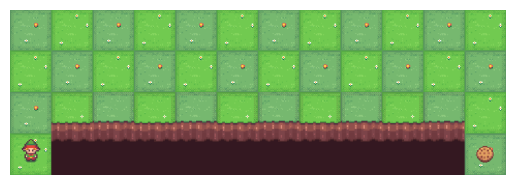

In [153]:
environment = gym.make("CliffWalking-v1", render_mode="rgb_array")
n_states = environment.observation_space.n
n_actions = environment.action_space.n
print(f"Miljøet har {n_states} antall tilstander og {n_actions} handlinger. ")

environment.reset()  # Initialize environment
frame = environment.render()  # Render a frame of the current state
plt.axis("off")  # Remove ticks in the figure
plt.imshow(frame)
plt.show()


Vi kan altså lage et nytt miljø med `environment = gym.make()`. Over printer vi ut antall mulige handlinger, og i tabulære miljøer kan vi også gjøre det for antall tilstander. Hver gang vi starter en ny episode må vi kalle `environment.reset()`, og `environment.render()` vil lage et bilde av miljøet. Vi kan ta valg i miljøet med `environment.step(action)`, der `action` er et heltall fra `0` til `n_actions - 1`. Dette vil returnere et tuppel av `next_state, reward, terminated, truncated, info`. Her er `next_state` et heltall tilsvarende neste tilstand, `reward` er belønningen, `terminated` er en boolsk verdi tilsvarende om vi har nådd en slutt-tilstand, `truncated` er en boolsk verdi for å sjekke om vi har nådd maks antall steg og `info` er mer data om miljøet. La oss prøve å ta et steg oppover.

Handlingen ga oss tilstanden 24 og belønningen -1. 


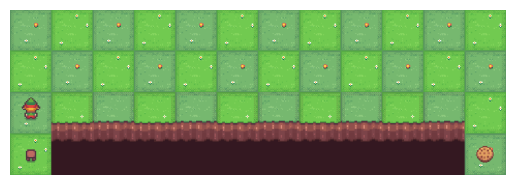

In [154]:
next_state, reward, terminated, truncated, info = environment.step(0)  # Take a step upwards
print(f"Handlingen ga oss tilstanden {next_state} og belønningen {reward}. ")
frame = environment.render()
plt.axis("off")  # Remove ticks in the figure
plt.imshow(frame)
plt.show()

Dere kan bruke den ferdiglagde funksjonen `train_agent()` til å trene en agent. Funksjonen tar strategien, oppdateringsregelen og andre hyperparametere som input og initialiserer et miljø og Q-tabell. Itererer deretter over miljøet med funksjonen `run_episode()`, som kjører gjennom en enkelt episode. I hver episode itererer man til enten `terminated` eller `truncated` blir `True`. Det blir tatt et valg ifølge strategien, og de returnerte verdiene blir brukt til å oppdatere Q-tabellen. Funksjonen `train_agent()` lagrer den totale belønningen fra hver episode og returnerer både Q-tabellen og de samlede belønningene.

Selv om dere ikke trenger implementere funksjonene `train_agent()` og `run_episode()` kan det være lurt å ta en titt på koden i filen `utils3b.py`, siden det kan hjelpe med forståelsen for hvordan vi trener agenten med algoritmene SARSA og Q-learning.

Til slutt kan en iterasjon over miljøet visualiseres med `visualize_episode()`, som gitt en Q-tabell animerer valgene steg for steg.

*Merk*: Tilstanden i miljøet blir representert med et heltall, som er ganske annerledes enn slik det visualiseres for mennesker. Fra bildet over kan vi enkelt se den beste veien til mål siden vi ser alle tilstandene representert samtidig. Agenten har derimot mindre informasjon, kun et heltall som representerer tilstanden, og får deretter gradvis informasjon om hvilke handlinger som fører til hvilke tilstander. Agenten kan altså ikke se mål for den plutselig ender opp i slutt-tilstanden. Dette bidrar til at agenten trenger å trenes over mange episoder for å lære selv om mennesker kan se svaret med en gang.

Dokumentasjonen til dette miljøet, og de andre miljøene vi skal bruke, [ligger her](https://gymnasium.farama.org/environments/toy_text/cliff_walking/).

### 2.1 - Trening på CliffWalking [6p]

La oss nå trene en agent på CliffWalking, både med SARSA og Q-læring. Bruk $\epsilon$-greedy eller softmax-strategi i begge tilfellene, og sett antall episoder lik 100 eller mindre. Finn passende verdier for hyperparameterne, altså $\epsilon$ (eller temperaturen dersom dere bruker softmax-strategi), læringsraten og diskonteringsfaktoren. Forsterkende læring har mye støy, så resultatene kan variere stort fra gang til gang selv om hyperparameterne er nesten like. Funksjonen `plot_rewards()` plotter belønningene over episodene, som kan gi en god innsikt over hvor bra hyperparameterne fungerte. Dette plottet vil ha mer støy enn plot med tap (loss) over epoker, så forvent høye avvik. Etter at agenten er trent og Q-tabellen er laget, kan vi bruke Q-tabellen sammen med en grådig strategi for å ta de beste valgene agenten kjenner til.

**Oppgave 2.1.1**: Tren en agent med SARSA. Under er et eksempel på hvordan funksjonene kan kalles. Finn hyperparametere som gjør at agenten kommer i mål på maksimum 17 trekk. Merk at eksempelverdiene gitt i koden ikke vil gi et godt resultat, så disse må endres for at agenten skal finne frem til mål.

- a) Eksperimenter med hyperparametere og finn en god konfigurasjon til å trene SARSA på CliffWalking. Inkluderer kun resultatene for de endelige hyperparameterne. Bruk `plot_rewards()` til å inspisere belønningen. For å unngå støy kan de første episodene unngås å plottes, ved `plot_rewards(rewards[:10])`.
- b) Bruk så `visualize_episode()` til å kjøre en iterasjon med Q-verdiene fra treningen og en grådig strategi. Finner agenten den beste veien? Hvorfor tror du den oppfører seg slik?

*Hint*: I miljøene vi bruker i denne obligen er det generelt sett lurt å bruke relativt høy diskonteringsfaktor.

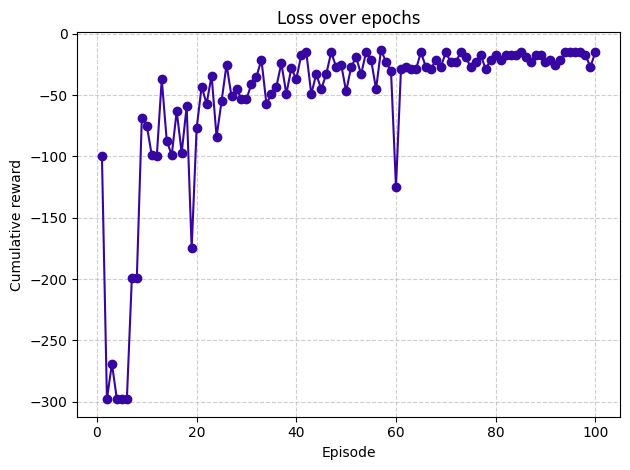

In [155]:
# Setter seed slik at vi får reproduserbare resultater
np.random.seed(seed=57)

n_episodes = 100  # Do not use a larger value than 100
# Setter SARSA som oppdateringsregel
update_function = sarsa_update

# Hyperparametere valgt for å gi agenten en god balanse mellom :
# - utforskning (epsilon)
# - hvor raskt den lærer (alpha)
# - hvor mye den bryr seg om fremtidige belønninger (gamma)
epsilon = 0.01
alpha = 0.4
gamma = 0.7

# Epsilon-greedy policy:
# - velger tilfeldig handling med sannsynlighet epsilon
# - velger ellers beste kjente handling
policy_function = EpsilonGreedyPolicy(epsilon=epsilon)

implemented = True

if implemented:
    # Trener agenten på CliffWalking
    # train_agent returnerer:
    # - q_table: den ferdigtrente Q-tabellen
    # - rewards: total belønning per episode
    q_table, rewards = train_agent(
        environment_name="CliffWalking-v1",
        n_episodes=n_episodes,
        policy_function=policy_function,
        update_function=update_function,
        alpha=alpha,
        gamma=gamma,
    )
    plot_rewards(rewards)

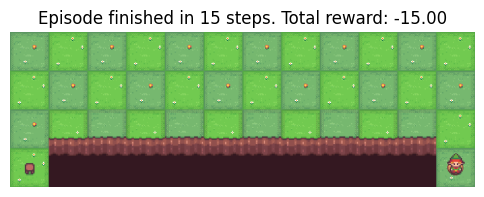

In [156]:
# Visalize in a different cell from the plotting, so that the plot does not get overwritten
if implemented:
    # Visualiserer én episode med greedy policy, etter trening
    # Nå brukes ikke legner epsilon-greedy, men greedy policy,
    # slik at agenten alltid velger handlingen med høyest Q-verdi.
    visualize_episode(
        environment_name="CliffWalking-v1",
        q_table=q_table,
        policy_function=greedy_policy,
        render_mode="rgb_array",
        delay=0.2,
    )

### Forklaring oppgave 2.1.1

I denne delen trentes en agent på CliffWalking med SARSA og en epsilon-greedy strategi. Etter å ha eksperimentert med hyperparameterne endre 'epsilon = 0.01', 'alpha = 0.4' og 'gamma = 0.7', og trente agenten i 100 episoder. Plottet viser at den kumulative belønningen blir gradvis mindre negativ utover treningen.. Dette betyr at agenten lærer underveis og etter hvert gjør bedre valg enn i starten. De første episodene har mer negative belønninger, noe som tyder på at agenten ofte bruker mange steg eller havner i dårlige situasjoner, mens resultatene senere blir mer stabile og mindre negative.

Visualiseringen etter treningen viser at agenten finner frem til målet på 15 steg. Ruten den velger går omtrent halvveis langs den midterste stien og deretter nærmere kanten før den når målet. Agenten finner altså ikke den mest direkte og risikoutsatte ruten, men en effektiv vei som kommer frem likevel. 
Dette passer godt med hvordan SARSA ofte oppfører seg. Siden SARSA er en on-policy metode, tar den hensyn til at agenten fortsatt kan utforske under trening. Derfor lærer den ofte en litt tryggere og mer konservativ strategi enn Q-learning. At agenten når målet på 15 steg viser også at en høyere gamma hjalp agenten med å nå målet ved å ta hensyn til fremtidige belønninger ved å planlegge over flere steg.

**Oppgave 2.1.2**: Tren en agent med Q-læring, tilsvarende som med SARSA.

- a) Finn gode hyperparametere for treningen og kall `plot_rewards()`. Inkluder kun én trening med de beste hyperparameterne.
- b) Bruk `visualize_episode()` med en grådig strategi til å visualisere resultatet. Hvordan er dette i forhold til resultatene med SARSA?

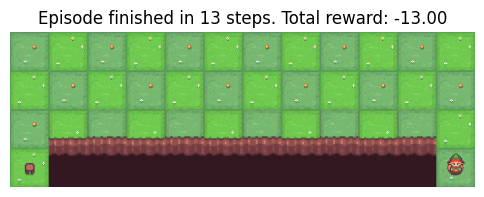

In [157]:
np.random.seed(seed=57)

n_episodes = 100  # Do not use a larger value than 100

# Velger Q-learning som oppdateringsregelen
update_function = q_learning_update

# Hyperparametrne
epsilon = 0.1
alpha = 0.5
gamma = 0.95

policy_function = EpsilonGreedyPolicy(epsilon=epsilon)

implemented = True

if implemented:
    # Trener agenten med Q-learning i stedet for SARSA
    q_table_q_learning, rewards_q_learning = train_agent(
        environment_name="CliffWalking-v1",
        n_episodes=n_episodes,
        policy_function=policy_function,
        update_function=update_function,
        alpha=alpha,
        gamma=gamma,
    )

    # Plotter belønningene for å sammenligne med SARSA
    plot_rewards(rewards=rewards_q_learning)

if implemented:
    # Visualiserer én episode etter Q-learning-treningen
    visualize_episode(
        environment_name="CliffWalking-v1",
        q_table=q_table_q_learning,
        policy_function=greedy_policy,
        render_mode="rgb_array",
        delay=0.2,
    )

### Forklaring - Oppgave 2.1.2
I denne delen trentes en agent på CliffWalking med Q-learning og en epsilon-greedy strategi. Hyperparameterne 'epsilon = 0.1', 'alpha = 0.5', og 'gamma = 0.95', og trente agenten i 100 episoder. 
Visualiseringen etter treningen viser at agenten finner den mest optimale veien til målet og fullfører episoden på 13 steg, som er det minste mulige. Dette er bedre enn resultatet med SARSA, som lærte en litt tryggere og mer forsiktig rute. En sannsynlig forkalring er at Q-learning bruker den beste mulige neste handlingen i oppdarginen og derfor oftere lærer en mer direkte og aggresiv strategi mot målet.

### 2.2 - Taxi [3p]

La oss nå prøve å trene i et miljø som inneholder tilfeldigheter. CliffWalking er et godt sted å starte for å trene enkle tabulære forsterkningslærings-agenter. Dette miljøet er *deterministisk*, som vil si at gitt en tilstand og handling vil miljøet alltid gi det samme utfallet. Mange realistiske kontekster er ikke så enkle og inneholder ofte tilfeldigheter i miljøet, slik at likt input kan gi forskjellig output. Vi kaller dette for et *stokastisk miljø* (stokastisk betyr egentlig bare "tilfeldig").

Vi skal nå bruke `Taxi`-miljøet. Dette baserer seg også på en tabulær verden, der agenten beveger seg rundt i en taxi. Det finnes noen vegger som ikke er mulig å gå igjennom, ellers kan den bevege seg fritt opp, til høyre, ned eller til venstre. Objektivet er å flytte seg til en passasjer, så laste passasjeren, deretter flytte seg til destinasjonen, deretter avlaste passasjeren. Det er fire mulige felt der passasjeren og destinasjonen kan starte, dette blir trukket tilfeldig hver gang en ny episode starter. Startposisjonen til taxien er også trukket tilfeldig. La oss se på dette visuelt. Vi laster inn to mulige start-posisjoner for å se at det starter tilfeldig.

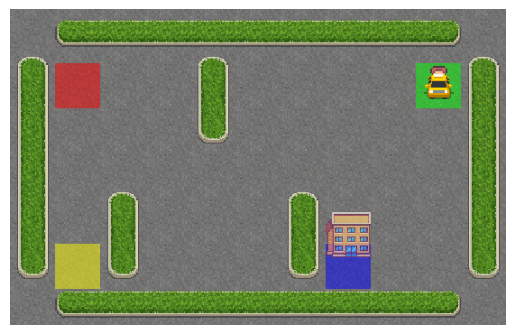

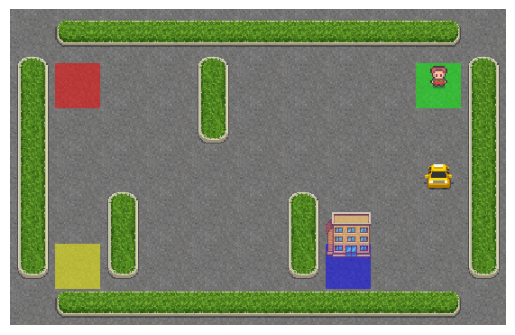

In [158]:
np.random.seed(seed=57)

environment = gym.make("Taxi-v3", render_mode="rgb_array")
environment.reset()  # Initialize environment
frame = environment.render()  # Render a frame of the current state

plt.axis("off")  # Remove ticks in the figure
plt.imshow(frame)
plt.show()

# Load one more starting position to see the randomness in the initialization
environment.reset()
frame = environment.render()
plt.axis("off")
plt.imshow(frame)
plt.show()

Objektivet er altså å først flytte taxien til passasjeren, laste på passasjeren, deretter flytte taxien til destinasjonen (huset på bildet) og laste passasjeren av. Handlingsrommet består av seks valg: Flytt opp, flytt høyre, flytt ned, flytt venstre, last på passasjer og last av passasjer. Det gis 20 i belønning for å laste av passasjeren, -10 dersom påstigning eller avstigning blir brukt ugyldig og -1 ellers.

Det er 500 mulige tilstander. Taxien har 25 mulige posisjoner, i tillegg kan passasjeren være i et av de fire startstedene eller i taxien og destinasjonen kan være et av fire steder (25 * 5 * 4 = 500). Tilstanden blir igjen representert med et heltall. Merk at noen av posisjonene er ikke mulig å nå, dersom passasjeren er samme sted som destinasjonen kan ikke taxien være et annet sted.

Det legges også til litt tilfeldighet i overgangene (transitions), altså når et valg blir tatt. Ved å sende med `is_rainy=True` vil taxien ha 80% sannsynlighet å flytte seg i retningen den prøver på og flytte seg til høyre eller venstre for den retningen med 10% sannsynlighet hver.

**Oppgave 2.2**: Finn gode hyperparametere, tren og evaluer på Taxi-miljøet. Bruk opp til 2000 episoder. Dere kan prøve dere frem med både SARSA og Q-læring. Dere kan starte med å sette `is_rainy=False` for å raskere komme frem til et godt resultat, men endre det tilbake til `True` etterpå. Siden miljøet er stokastisk, iterer over fem forskjellige visualiseringer som i koden under. Prøv å tren en agent som i de fleste kjøringene oppnår en positiv belønning (dette vil variere mye med tilfeldighetene i miljøet). Inkluder kun resultatene fra de beste hyperparameterne. Kommenter resultatene.

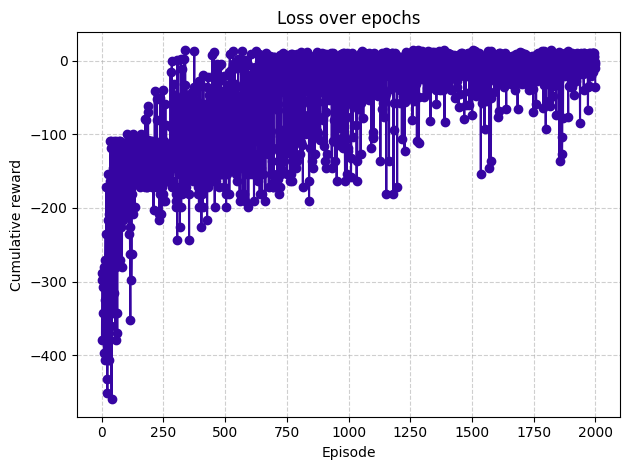

In [164]:
np.random.seed(seed=57)

n_episodes = 2000  # Do not use a larger value than 2000
args = {"max_episode_steps": 100, "is_rainy": True}  # Truncate (stop) after 100 steps. Use randomness in transitions

epsilon = 0.1
alpha = 0.2
gamma = 0.95
update_function = sarsa_update
# update_function = q_learning_update
policy_function = EpsilonGreedyPolicy(epsilon=epsilon)
implemented = True

if implemented:
    q_table, rewards = train_agent(
        environment_name="Taxi-v3",
        n_episodes=n_episodes,
        policy_function=policy_function,
        update_function=update_function,
        alpha=alpha,
        gamma=gamma,
        environment_args=args,
    )
    plot_rewards(rewards=rewards)

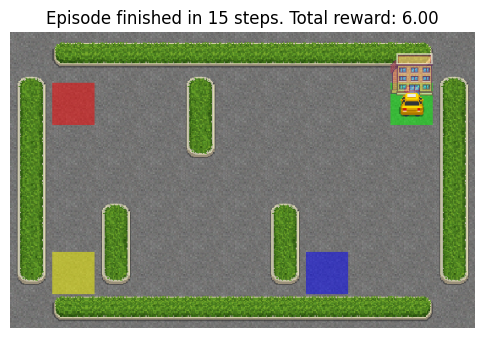

In [165]:
if implemented:
    # Kjører flere visualiseringer fordi miljøet er stokastisk
    # og resultater kan variere fra episode til episode.
    for _ in range(5):
        visualize_episode(
            environment_name="Taxi-v3",
            q_table=q_table,
            policy_function=greedy_policy,
            render_mode="rgb_array",
            delay=0.05,
            environment_args=args,
        )

### Forklaring - Oppgave 2.2 Taxi

I denne delen trente jeg en agent på Taxi-miljøet, som er mer krevende enn CliffWalking fordi miljøet er stokastisk. Jeg brukte 'SARSA' som oppdateringsregel, 'EpsilonGreedyPolicy' med 'epsilon = 0.1', 'alpha = 0.2' og 'gamma = 0.95', og trente i 2000 episoder med 'is_rainy=True'. Det betyr at agenten ikke alltid beveger seg nøyaktig dit den prøver, noe som gjør oppgaven mer realistisk og vanskeligere å lære.

Plottet viser at den kumulative belønningen blir tydelig bedre utover treningen. I starten er belønningene svært negative, noe som er forventet fordi agenten ofte bruker mange unødvendige steg og gjør dårlige valg før den har lært miljøet. Etter hvert stiger belønningene og samler seg høyere i plottet, som viser at agenten gradvis lærer en bedre strategi. Det er fortsatt en del variasjon, men det er naturlig siden miljøet inneholder tilfeldighet.

Visualiseringene viser at agenten i praksis fungerer veldig bra. Selv om rutene ikke alltid er helt optimale, men taxien når målet i alle kjøringene og gjør det også ganske raskt med relativt lave negative belønninger. Dette tyder altså på at agenten har lært en robust strategi som fungerer godt selv når overgangene i miljøet er usikre.

En viktig observasjon var at når jeg forsøkte å "forbedre" grafen ved å få enda lavere og roligere verdier, endte agenten ofte opp med å stå stille eller bevege seg frem og tilbake uten å fullføre oppgaven. Da unngikk den rett og slett straffebelønninger, og lærte derfor ikke å løse problemet. Dette viser at "penere" plott ikke betyr en bedre agent i alle tilfeller. Det viktigste er at agenten faktsik når målet og løser oppgaven, ikke bare at grafen ser mindre støyete ut.

**[Bonus] Funksjonsapproksimasjon**: Vi har i dette faget holdt oss til *tabulære* tilfeller, altså der vi kan gi en verdi til hver eneste kombinasjon av tilstander og handlinger. Det blir fort upraktisk og ofte umulig. Om man for eksempel spiller sjakk er rundt 10^43 posisjoner, altså et tall med 43 nuller. Dette er astronomisk høyt og helt umulig å fange opp som et tabulært tilfelle. Sjakk er ikke unntaket, i de fleste praktiske miljøer der en agent kan bevege seg fritt blir det for mange tilstander til at man kan modellere dem én og én. Allikevel er det mulig å lage agenter som lærer sjakk med forsterkende læring og andre krevende miljøer. Trikset som gjør det mulig å trene agenter i disse miljøene er kalt *funksjonsapproksimasjon*. Istedenfor å ha en verdi til hver mulighet, bruker vi en funksjon som tar tilstanden som input, og som gir enten handlingen, Q-verdien eller tilsvarende som output. I praksis er det vanlig at denne funksjonen er et dypt nevralt nettverk, som gir opphavet til *dyp forsterkende læring* (deep reinforcement learning). Nesten alle tilfeller av moderne forsterkende læring bruker en form for nevrale nettverk.

### [Bonus] 2.3 - FrozenLake [3b]

Dersom dere har lyst på en utfordring der vi også jobber med å endre belønningen fra miljøet kan dere se på `FrozenLake`, som er et miljø som kan se enklere ut enn det faktisk er. Miljøet er nok et tabulært miljø der objektive er å flytte fra start til en slutt-tilstand. I tillegg er det flere hull, som dersom agenten går bort i faller ned og episoden slutter. La oss se på det visuelt.

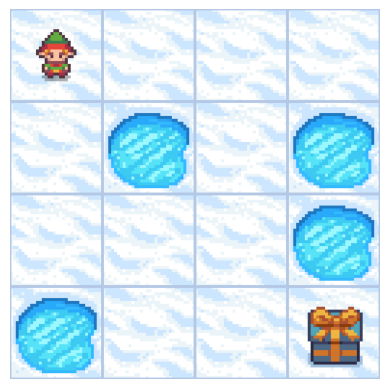

In [166]:
environment = gym.make("FrozenLake-v1", render_mode="rgb_array")
environment.reset()
frame = environment.render()

plt.axis("off")
plt.imshow(frame)
plt.show()


Dette kan i utgangspunktet se enkelt ut, men det er noen utfordringer som gjør det vanskeligere. Isen er glatt, så agenten vil kun flytte i retningen den prøver med sannsynlighet `success_rate`, som vi setter til `0.7`. I tillegg er belønningene sjeldne (sparse), miljøet returnerer 1 for å nå slutten og 0 ellers. Dette er en utfordring siden agenten ikke blir straffet for å gjøre unødvendige trekk, og det blir heller ingen direkte straff for å falle i et hull annet enn at man mister muligheten til å nå målet. Derfor er det mulig å endre belønningen som del av å justere hyperparameterne. Dere kan også endre maksimum antall steg før miljøet slutter tidlig (`max_episode_steps`).

**Oppgave 2.3**: Juster hyperparameter, tren og evaluer på `FrozenLake`-miljøet. I tillegg til å justere alpha og gamma kan dere justere belønningene gjennom `reward_schedule`. Bruk opp til 2000 episoder. Dere vil nok oppleve at det er krevende å finne gode hyperparametere her. Det er forventet, forsterkningslæring har mange tilfeldigheter og krever ofte mye prøving og feiling. Iterer over fem miljøer i evalueringen siden miljøet er tilfeldig. *Hint*: Dersom dere har implementert `SoftmaxPolicy` kan denne komme til hjelp. Dere kan prøve å sette `is_slippery` til `False` for å komme i gang. Det er også mulig å bruke `map_name="8x8"` for et større miljø, men da kreves det nok mer enn 2000 episoder.

In [167]:
np.random.seed(seed=57)

n_episodes = 5000
update_function = sarsa_update

alpha = 0.1
gamma = 0.9
policy_function = None
args = {
    "is_slippery": True,  # Do not change this, expect for testing
    "success_rate": 0.7,  # Do not change this
    "map_name": "4x4",  # This can be changed to "8x8" for an extra challenge
    "max_episode_steps": 100,  # Can be changed, but probably does not matter much
    "reward_schedule": (1, 0, 0),  # Rewards for (goal, hole, other-movement). Can be changed.
}

implemented = False

if implemented:
    q_table, rewards = train_agent(
        environment_name="FrozenLake-v1",
        n_episodes=n_episodes,
        policy_function=policy_function,
        update_function=update_function,
        alpha=alpha,
        gamma=gamma,
        environment_args=args,
    )
    plot_rewards(rewards=rewards)

In [168]:
if implemented:
    for _ in range(5):
        visualize_episode(
            environment_name="FrozenLake-v1",
            q_table=q_table,
            policy_function=greedy_policy,
            render_mode="rgb_array",
            delay=0.2,
            environment_args=args,
        )

## Oppsummering

I denne obligen har vi implementert flere strategier (policies) brukt i forsterkende læring sammen med oppdateringsregelen for SARSA og Q-læring. Vi har trent og evaluert agenter på flere miljøer fra det populære biblioteket `gymnasium`. Vi har holdt oss til tabulære tilfeller, der vi kan ha en verdi for hver kombinasjon av tilstand og handling.

Dersom dere har lyst til å lære mer om forsterkningslæring, er en god mulighet å starte med å se på noen av mange artige og informative videoer som viser hvordan forsterkningslæringsalgoritmer kan bli brukt, slik som denne](https://www.youtube.com/watch?v=hCmrMOzx5VA) og [denne](https://www.youtube.com/watch?v=EWjUY_3ubf4). Dere vil også lære mer om forsterkningslæring i faget IN2160.

For mer detaljert materiale er [denne videoserien](https://www.youtube.com/playlist?list=PLzvYlJMoZ02Dxtwe-MmH4nOB5jYlMGBjr) sterkt anbefalt. Den går igjennom fundamentet til forsterkningslæring i mer detalj og dekker flere områder vi ikke har gått inn på i dette faget. Den baserer seg på boken som regnes som "reinforcement-learning bibelen", som kan [leses her](http://www.incompleteideas.net/book/RLbook2020.pdf). Merk at den er noe mer avansert enn nivået vi har hatt i dette faget. OpenAI har laget en introduksjon til dyp forsterkningslæring (forsterkningslæring med nevrale nettverk) kalt "Spinning up", [tilgjengelig her](https://spinningup.openai.com/en/latest/). Dette materiale er også noe mer krevende.